# Gated multimodal experiments

Linear two-stream model with per-voxel video / audio gate (`α`).

* **No PCA** on either modality — full-resolution 768-d ViT features and
  15-d MFCC features feed two independent ridge regressions.
* **No neural networks** — three closed-form solves.
* Three baselines compared throughout: **audio-only**, **video-only**,
  **gated multimodal**.
* All α / improvement maps are overlaid on the mean BOLD and masked to
  brain voxels (Otsu + temporal-variance) ∩ confident voxels
  (predictability + modality-separability).


## 1 · Imports and setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid', palette='Set2')

from sklearn.preprocessing import StandardScaler

from data_loading import (
    Sub,
    get_audio_encoding,
    get_rich_audio_encoding,
    get_deep_audio_encoding,
    get_video_encoding,
    _resample_to_grid,
    brain_mask,
    make_brain_mask_for_sub,
)
from models import LinearDeltaModel
from gated_models import GatedMultimodalLinearDeltaModel
from brain_viz import show_alpha_overlay, show_signed_overlay
import utils

In [2]:
# !pip install librosa
# !apt-get install -y libgl1
# !pip install seaborn
# !pip install nibabel

## 2 · Build full-resolution feature matrices

Both modalities are resampled to the same time grid and standardised
(per-modality `StandardScaler`).


In [3]:
# Audio feature selector.
#   'mfcc'   -> legacy 15-d MFCC                          (fastest, weakest)
#   'rich'   -> 144-d hand-crafted multi-family features  (mid-range)
#   'hubert' -> 768-d HuBERT-base transformer embeddings  (best, ~360 MB DL)
#   'wav2vec2' -> 768-d wav2vec2-base embeddings          (alternative)
AUDIO_FEATURES = 'hubert'

if AUDIO_FEATURES == 'mfcc':
    X_audio_raw = get_audio_encoding(n_mfcc=15)
elif AUDIO_FEATURES == 'rich':
    X_audio_raw = get_rich_audio_encoding()
elif AUDIO_FEATURES in ('hubert', 'wav2vec2'):
    model_name = 'hubert_base' if AUDIO_FEATURES == 'hubert' else 'wav2vec2_base'
    X_audio_raw = get_deep_audio_encoding(
        cache_path=f'src/{model_name}_features.npy',
        model_name=model_name,
        segment_s=30.0,
        layer=-1,            # try layer=8 or 9 for better auditory-cortex alignment
    )
else:
    raise ValueError(f'Unknown AUDIO_FEATURES={AUDIO_FEATURES!r}')
print('Audio raw shape:', X_audio_raw.shape)

# Video (768-d ViT-B/16) — chunk_dir bounds peak RAM during encoding.
X_video_raw = get_video_encoding(
    video_path='src/Film stimulus.mp4',
    cache_path='src/vit_b16_features.npy',
    chunk_dir='src/vit_b16_chunks',
    chunk_size=512,
)
print('Video raw shape:', X_video_raw.shape)

# Resample both modalities to a common 25 fps × 390 s grid.
n_target = int(25.0 * 390.0)
t_target = np.linspace(0.0, 1.0, n_target)

X_video = StandardScaler().fit_transform(_resample_to_grid(X_video_raw, t_target))
X_audio = StandardScaler().fit_transform(_resample_to_grid(X_audio_raw, t_target))
print('X_video:', X_video.shape, '  X_audio:', X_audio.shape)

[AudioEncoder] Loading cached embeddings from src/hubert_base_features.npy
Audio raw shape: (19515, 768)
[VideoEncoder] Loading cached embeddings from src/vit_b16_features.npy
Video raw shape: (9750, 768)
X_video: (9750, 768)   X_audio: (9750, 768)


## 3 · Subject and hyperparameters

In [4]:
SUB_ID  = '22' # '04'
DT      = 4       # Hemodynamic delay, seconds
COEF    = 2       # AvgPool factor on the BOLD volume
ALPHA_V = 2e2     # Ridge penalty for the (high-dim) video block
ALPHA_A = 2e2     # Ridge penalty for the audio block.  With block_normalize=True
                  # below the two blocks are on the same scale, so equal alphas
                  # is a principled default.

# Tell the loader where the BIDS dataset lives.  Set once on the class so
# every subsequent Sub(sid) call below picks it up automatically.
Sub.DATA_ROOT = '/Users/anastasiia/8_semester/диплом/код'

sub = Sub(SUB_ID, data_root=Sub.DATA_ROOT)
print('BOLD volume shape:', sub.tensor.shape)

# Brain mask on the SAME downsampled grid the models use (AvgPool with
# coef=COEF).  All MSEs from this point on are restricted to these
# voxels — averaging over background air voxels would just dilute the
# signal and make every model look comparably good.
brain_mask_3d = make_brain_mask_for_sub(sub, COEF, var_quantile=1e-3)
brain_mask_flat = brain_mask_3d.reshape(-1)
print(f'Brain mask: {brain_mask_flat.sum()} / {brain_mask_flat.size} voxels '
      f'({brain_mask_flat.mean() * 100:.1f}%)')

BOLD volume shape: torch.Size([40, 64, 64, 641])
Brain mask: 2386 / 20480 voxels (11.7%)


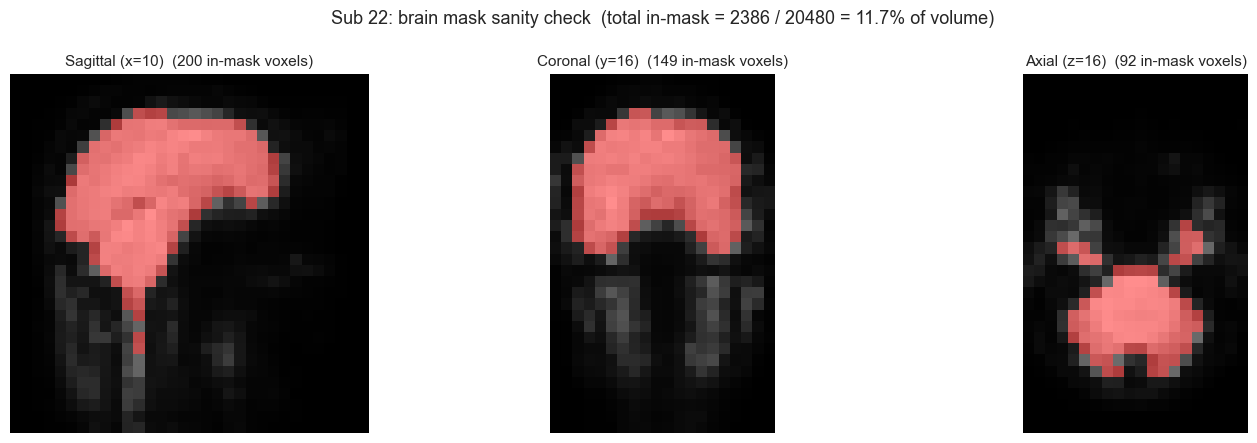

In [5]:
import torch

# Recompute mean BOLD on the SAME downsampled grid the mask was built on.
if COEF > 1:
    _pooled = torch.nn.AvgPool3d(COEF, stride=COEF)(
        sub.tensor.permute(3, 0, 1, 2)
    ).permute(1, 2, 3, 0)
else:
    _pooled = sub.tensor
_mean_bold = _pooled.numpy().mean(axis=-1)

d1, d2, d3 = brain_mask_3d.shape
slice_specs = [
    (0, d1 // 2, 'Sagittal (x={})'),
    (1, d2 // 2, 'Coronal (y={})'),
    (2, d3 // 2, 'Axial (z={})'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (dim, sl, title_template) in zip(axes, slice_specs):
    if dim == 0:
        bg, msk = _mean_bold[sl, :, :].T, brain_mask_3d[sl, :, :].T
    elif dim == 1:
        bg, msk = _mean_bold[:, sl, :].T, brain_mask_3d[:, sl, :].T
    else:
        bg, msk = _mean_bold[:, :, sl].T, brain_mask_3d[:, :, sl].T

    # Build an RGBA overlay: semi-opaque red where mask=True, transparent elsewhere.
    rgba = np.zeros((*msk.shape, 4), dtype=float)
    rgba[msk] = [1.0, 0.0, 0.0, 0.45]

    ax.imshow(bg, cmap='gray', origin='lower')
    ax.imshow(rgba, origin='lower')
    ax.set_title(
        title_template.format(sl) + f'  ({int(msk.sum())} in-mask voxels)',
        fontsize=11,
    )
    ax.axis('off')

fig.suptitle(
    f'Sub {SUB_ID}: brain mask sanity check  '
    f'(total in-mask = {int(brain_mask_3d.sum())} / {brain_mask_3d.size} '
    f'= {brain_mask_3d.mean() * 100:.1f}% of volume)',
    fontsize=13,
)
plt.tight_layout()
# plt.savefig(f'brain_mask_check_sub{SUB_ID}.pdf', bbox_inches='tight')
plt.show()

## 4 · Single-modality baselines

Two reference models — one per modality — reusing the existing
`LinearDeltaModel`.  Same delay `DT` and AvgPool `COEF` as the gated
model so the train/test splits are identical and MSEs are directly
comparable.


In [6]:
audio_model = LinearDeltaModel(X_audio, sub, DT, COEF, ALPHA_A)
audio_model.fit(); audio_model.predict()
audio_model.evaluate(mask=brain_mask_flat)
print(f'[Audio-only]  MSE_test (brain-masked) = {audio_model.MSE_test:.4e}')

video_model = LinearDeltaModel(X_video, sub, DT, COEF, ALPHA_V)
video_model.fit(); video_model.predict()
video_model.evaluate(mask=brain_mask_flat)
print(f'[Video-only]  MSE_test (brain-masked) = {video_model.MSE_test:.4e}')

[Audio-only]  MSE_test (brain-masked) = 1.0688e-04
[Video-only]  MSE_test (brain-masked) = 1.0799e-04


## 5 · Gated multimodal model

Three closed-form solves: video-only ridge, audio-only ridge, then the
per-voxel scalar gate `α`.


In [7]:
gated = GatedMultimodalLinearDeltaModel(
    X_video=X_video,
    X_audio=X_audio,
    sub=sub,
    dt=DT,
    coef=COEF,
    alpha_video=ALPHA_V,
    alpha_audio=ALPHA_A,
)
gated.fit(); gated.predict()
gated.evaluate(mask=brain_mask_flat)

print(f'[Gated multimodal]  MSE_test (brain-masked) = {gated.MSE_test:.4e}')

contrib = gated.modality_mse(mask=brain_mask_flat)
print()
print('Per-modality MSE on the test set (brain voxels only):')
for name, mse in contrib.items():
    print(f'  {name:6s}  MSE = {mse:.4e}')

# Same-fit comparison: contrib['audio'] is the same separate audio ridge as
# audio_model (no block normalisation here), so these two numbers should be
# numerically very close.  The "Improvement" lines therefore measure the
# benefit of the alpha-mixing step, not a regularisation difference.
print()
print('Improvement of gated model over single-modality baselines (brain voxels):')
delta_a = (audio_model.MSE_test - gated.MSE_test) / audio_model.MSE_test * 100
delta_v = (video_model.MSE_test - gated.MSE_test) / video_model.MSE_test * 100
print(f'  vs audio-only:  {delta_a:+.3f}%')
print(f'  vs video-only:  {delta_v:+.3f}%')

[Gated multimodal]  MSE_test (brain-masked) = 9.8033e-05

Per-modality MSE on the test set (brain voxels only):
  video   MSE = 1.0799e-04
  audio   MSE = 1.0688e-04
  gated   MSE = 9.8033e-05

Improvement of gated model over single-modality baselines (brain voxels):
  vs audio-only:  +8.276%
  vs video-only:  +9.222%


## 6 · Distribution of α — how do voxels split between modalities?

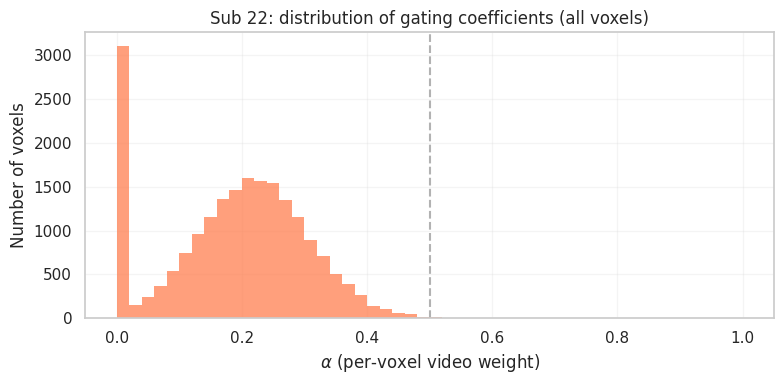

Video-dominant voxels (α > 0.6):       6  (0.0%)
Audio-dominant voxels (α < 0.4):   20086  (98.1%)
Mixed voxels (0.4 ≤ α ≤ 0.6):        388  (1.9%)


In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(gated.alpha, bins=50, color='coral', edgecolor='none', ax=ax)
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.6)
ax.set_xlabel(r'$\alpha$ (per-voxel video weight)')
ax.set_ylabel('Number of voxels')
ax.set_title(f'Sub {SUB_ID}: distribution of gating coefficients (all voxels)')
plt.grid(alpha=0.2)
plt.tight_layout()
# plt.savefig(f'alpha_dist_sub{SUB_ID}.pdf', bbox_inches='tight')
plt.show()

n_video = (gated.alpha > 0.6).sum()
n_audio = (gated.alpha < 0.4).sum()
n_mixed = ((gated.alpha >= 0.4) & (gated.alpha <= 0.6)).sum()
total = gated.alpha.size

print(f'Video-dominant voxels (α > 0.6):  {n_video:>6d}  ({n_video / total * 100:.1f}%)')
print(f'Audio-dominant voxels (α < 0.4):  {n_audio:>6d}  ({n_audio / total * 100:.1f}%)')
print(f'Mixed voxels (0.4 ≤ α ≤ 0.6):     {n_mixed:>6d}  ({n_mixed / total * 100:.1f}%)')

CGMM-2 fit on continuous component (n_inner = 2381):
  comp 1:  pi=0.679, mu=0.2301, s=0.0735
  comp 2:  pi=0.321, mu=0.3069, s=0.0773
  Boundary masses:  p0_hat = 0.0021,  p1_hat = 0.0000

Goodness of fit on continuous component:
  D (KS effect size):  0.0072
  W1 (Wasserstein-1):  0.0010
  Rules of thumb:  D < 0.05 = tight,  W1 < 0.01 = tight.


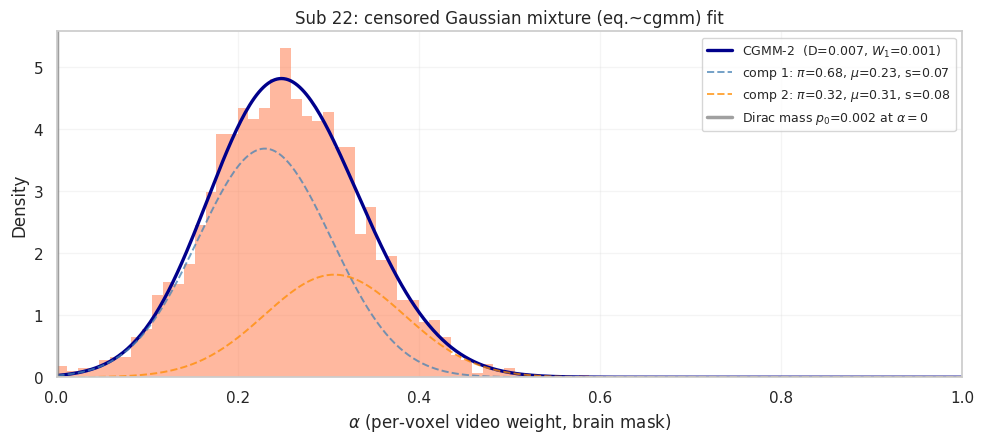

In [9]:
# === Censored Gaussian Mixture (CGMM) fit for the per-voxel gate ===
# Theoretically derived from the Gaussian-noise probabilistic regression
# model (Proposition 2 in the paper, eq:cgmm).  Replaces the phenomenological
# 2-Beta mixture as a first-principles parametric form on [0, 1].


from scipy import stats
import numpy as np

# 1. Brain-masked α
alpha_brain = gated.alpha[brain_mask_flat]
EPS = 1e-3

# 2. Empirical Dirac masses at boundaries
p0_hat = float((alpha_brain < EPS).mean())
p1_hat = float((alpha_brain >= 1 - EPS).mean())

# 3. Continuous component
alpha_inner = alpha_brain[(alpha_brain >= EPS) & (alpha_brain < 1 - EPS)]
n_inner = alpha_inner.size

# Truncated-normal helpers on (0, 1)
def trunc_norm_pdf(x, mu, s):
    a = (0.0 - mu) / s
    b = (1.0 - mu) / s
    Z = stats.norm.cdf(b) - stats.norm.cdf(a)
    return stats.norm.pdf((x - mu) / s) / (s * max(Z, 1e-12))

def trunc_norm_cdf(x, mu, s):
    a = (0.0 - mu) / s
    b = (1.0 - mu) / s
    Z = stats.norm.cdf(b) - stats.norm.cdf(a)
    return (stats.norm.cdf((x - mu) / s) - stats.norm.cdf(a)) / max(Z, 1e-12)

# 4. EM for K-component truncated Gaussian mixture on (0, 1)
def fit_trunc_gmm(x, K=2, n_iter=300):
    n = x.size
    # Init: K-quantile means, common scale = std(x) / K
    qs = np.quantile(x, np.linspace(0, 1, K + 1))
    mu = np.array([0.5 * (qs[k] + qs[k + 1]) for k in range(K)])
    s  = np.full(K, max(np.std(x) / K, 1e-3))
    pi = np.full(K, 1.0 / K)
    for _ in range(n_iter):
        # E-step: responsibilities
        log_w = np.column_stack([
            np.log(pi[k] + 1e-12)
            + np.log(np.maximum(trunc_norm_pdf(x, mu[k], s[k]), 1e-300))
            for k in range(K)
        ])
        log_w -= log_w.max(axis=1, keepdims=True)
        w = np.exp(log_w)
        w /= w.sum(axis=1, keepdims=True)
        # M-step (moment-matching)
        pi = w.mean(axis=0)
        for k in range(K):
            wk = w[:, k]
            wk = wk / max(wk.sum(), 1e-12)
            mu[k] = float((wk * x).sum())
            s[k]  = float(np.sqrt(max((wk * (x - mu[k])**2).sum(), 1e-6)))
    return pi, mu, s

pi_g, mu_g, s_g = fit_trunc_gmm(alpha_inner, K=2)

print(f'CGMM-2 fit on continuous component (n_inner = {n_inner}):')
for k in range(2):
    print(f'  comp {k+1}:  pi={pi_g[k]:.3f}, mu={mu_g[k]:.4f}, s={s_g[k]:.4f}')
print(f'  Boundary masses:  p0_hat = {p0_hat:.4f},  p1_hat = {p1_hat:.4f}')

# 5. Goodness of fit on continuous component
x_sorted = np.sort(alpha_inner)
F_emp = np.arange(1, n_inner + 1) / n_inner
F_fit = sum(pi_g[k] * trunc_norm_cdf(x_sorted, mu_g[k], s_g[k]) for k in range(2))
D_cgmm = float(np.max(np.abs(F_emp - F_fit)))

# Wasserstein via inverse-CDF sampling from the truncated-Gaussian mixture
rng = np.random.default_rng(0)
n_samp = 20_000
comp = rng.choice(2, size=n_samp, p=pi_g)
samples = np.empty(n_samp)
for k in range(2):
    sel = comp == k
    n_k = int(sel.sum())
    if n_k:
        a = (0.0 - mu_g[k]) / s_g[k]
        b = (1.0 - mu_g[k]) / s_g[k]
        Phi_a, Phi_b = stats.norm.cdf(a), stats.norm.cdf(b)
        u = rng.random(n_k)
        z = stats.norm.ppf(Phi_a + u * (Phi_b - Phi_a))
        samples[sel] = mu_g[k] + s_g[k] * z

W1_cgmm = stats.wasserstein_distance(alpha_inner, samples)

print(f'\nGoodness of fit on continuous component:')
print(f'  D (KS effect size):  {D_cgmm:.4f}')
print(f'  W1 (Wasserstein-1):  {W1_cgmm:.4f}')
print(f'  Rules of thumb:  D < 0.05 = tight,  W1 < 0.01 = tight.')

# 6. Visualisation
xx = np.linspace(EPS, 1 - EPS, 400)
pdf_total = sum(pi_g[k] * trunc_norm_pdf(xx, mu_g[k], s_g[k]) for k in range(2))

fig, ax = plt.subplots(figsize=(10, 4.6))
sns.histplot(alpha_brain, bins=50, stat='density',
             color='coral', edgecolor='none', alpha=0.55, ax=ax)
ax.plot(xx, pdf_total * (1 - p0_hat - p1_hat),
        color='darkblue', lw=2.4, ls='-',
        label=fr'CGMM-2  (D={D_cgmm:.3f}, $W_1$={W1_cgmm:.3f})')
for k in range(2):
    comp_pdf = pi_g[k] * trunc_norm_pdf(xx, mu_g[k], s_g[k])
    ax.plot(xx, comp_pdf * (1 - p0_hat - p1_hat),
            color=['steelblue', 'darkorange'][k], lw=1.4, ls='--', alpha=0.75,
            label=fr'comp {k+1}: $\pi$={pi_g[k]:.2f}, $\mu$={mu_g[k]:.2f}, s={s_g[k]:.2f}')
ax.axvline(0, color='gray', lw=2.5, alpha=0.75,
           label=fr'Dirac mass $p_0$={p0_hat:.3f} at $\alpha=0$')
ax.set_xlabel(r'$\alpha$ (per-voxel video weight, brain mask)')
ax.set_ylabel('Density')
ax.set_title(f'Sub {SUB_ID}: censored Gaussian mixture (eq.~cgmm) fit')
ax.set_xlim(0, 1)
ax.legend(loc='upper right', fontsize=9)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(f'alpha_cgmm_fit_brain_sub{SUB_ID}.pdf', bbox_inches='tight')
plt.show()

## 7 · Build masks — anatomy + confidence

Two masks are combined for every overlay below:

* **Brain mask** (`data_loading.brain_mask`) — Otsu on the temporal-mean
  BOLD intensity to drop air, plus a 10-th percentile temporal-variance
  cut to drop static-noise voxels (skull, etc.).
* **Confidence mask** (`gated.confidence_mask`) — voxels where the
  gated model is actually informative: predictable test-set R² and
  separable video / audio predictions.


In [10]:
# brain_mask_3d / brain_mask_flat were already built in §3 (cell 6) on
# the same downsampled grid the models use.  Here we just add the
# confidence mask layer needed for the *visualisation* overlays.
conf_mask_3d = gated.confidence_volume(
    predictability_quantile=0.5,
    separability_quantile=0.3,
)

# Mask used for the colour overlays below: brain ∩ confident.
show_mask = brain_mask_3d & conf_mask_3d
print(f'Brain voxels (Otsu+var):       {brain_mask_3d.sum():>6d}  '
      f'({brain_mask_3d.mean()*100:.1f}% of volume)')
print(f'Confident voxels:              {conf_mask_3d.sum():>6d}  '
      f'({conf_mask_3d.mean()*100:.1f}% of volume)')
print(f'Brain ∩ confident (overlay):   {show_mask.sum():>6d}  '
      f'({show_mask.mean()*100:.1f}% of volume)')

# Mean BOLD for use as a grayscale underlay
mean_bold = gated.mean_bold_volume()
print('Underlay (mean BOLD) shape:', mean_bold.shape)

Brain voxels (Otsu+var):         2445  (11.9% of volume)
Confident voxels:                7201  (35.2% of volume)
Brain ∩ confident (overlay):      742  (3.6% of volume)
Underlay (mean BOLD) shape: (20, 32, 32)


## 7.1 · α distribution restricted to confident brain voxels

The full-volume histogram in §6 is dominated by background voxels.  Re-run
it within the brain∩confident mask to see the *real* split.


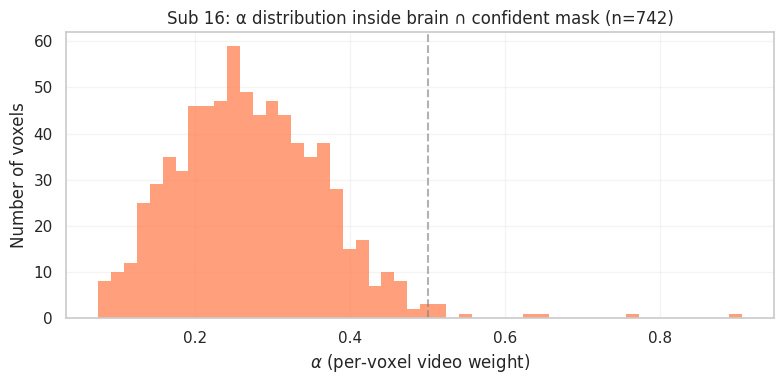

Within mask:  ⟨α⟩ = 0.272, median = 0.264
  video-dominant (α > 0.6):  0.5%
  audio-dominant (α < 0.4):  92.0%


In [11]:
alpha_in_mask = gated.alpha_volume()[show_mask]

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(alpha_in_mask, bins=50, color='coral', edgecolor='none', ax=ax)
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.6)
ax.set_xlabel(r'$\alpha$ (per-voxel video weight)')
ax.set_ylabel('Number of voxels')
ax.set_title(
    f'Sub {SUB_ID}: α distribution inside brain ∩ confident mask '
    f'(n={alpha_in_mask.size})'
)
plt.grid(alpha=0.2)
plt.tight_layout()
# plt.savefig(f'alpha_dist_masked_sub{SUB_ID}.pdf', bbox_inches='tight')
plt.show()

print(f'Within mask:  ⟨α⟩ = {alpha_in_mask.mean():.3f}, '
      f'median = {np.median(alpha_in_mask):.3f}')
print(f'  video-dominant (α > 0.6):  '
      f'{(alpha_in_mask > 0.6).mean()*100:.1f}%')
print(f'  audio-dominant (α < 0.4):  '
      f'{(alpha_in_mask < 0.4).mean()*100:.1f}%')

## 8 · 3-D map of α — overlaid on the BOLD anatomy

Red = video-driven (α → 1), blue = audio-driven (α → 0).  Voxels outside
the mask show only the underlay (no colour).


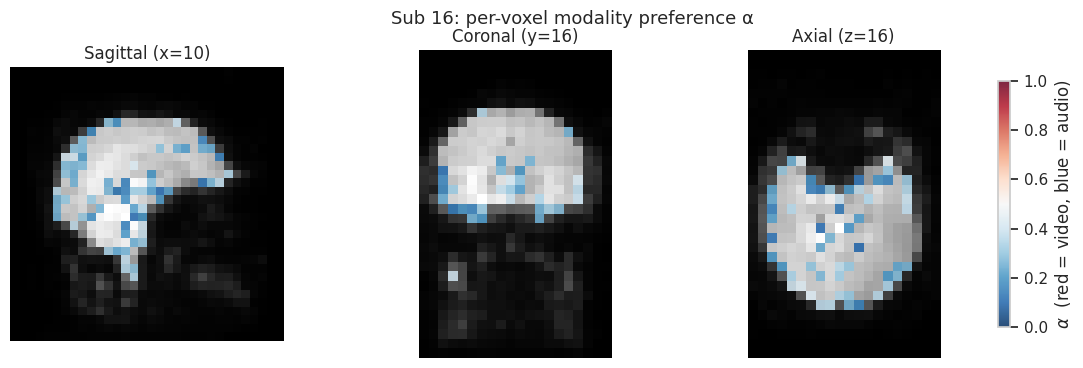

In [12]:
show_alpha_overlay(
    alpha_3d=gated.alpha_volume(),
    bold_underlay=mean_bold,
    mask_3d=show_mask,
    title=f'Sub {SUB_ID}: per-voxel modality preference α',
    # save_path=f'alpha_overlay_sub{SUB_ID}.pdf',
)

## 9 · Per-voxel improvement vs audio-only

Where does the gated model beat audio-only?  Red = gated wins, blue =
audio wins.


Within brain mask: joint model beats audio in 2440/2445 voxels (99.8%)


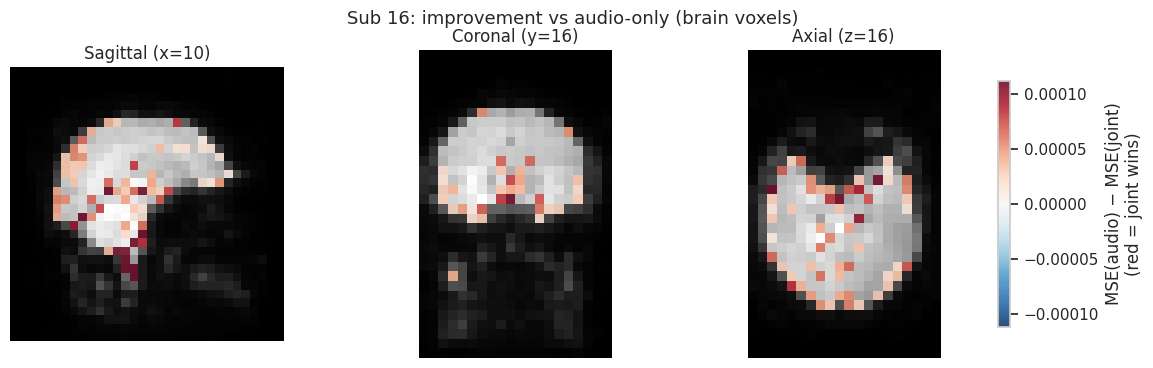

In [13]:
true_test = np.delete(gated.Y_test, 0, 1)
err_audio = np.mean(
    (audio_model.Y_test_predicted - np.delete(audio_model.Y_test, 0, 1)) ** 2,
    axis=1,
)
err_gated = np.mean((gated.Y_test_predicted - true_test) ** 2, axis=1)
imp_vs_audio = err_audio - err_gated

# Stats restricted to brain voxels (background voxels would inflate the count).
n_win = (imp_vs_audio[brain_mask_flat] > 0).sum()
n_total = int(brain_mask_flat.sum())
print(f'Within brain mask: joint model beats audio in {n_win}/{n_total} voxels '
      f'({n_win / max(n_total, 1) * 100:.1f}%)')

show_signed_overlay(
    values_3d=imp_vs_audio.reshape(gated._d1, gated._d2, gated._d3),
    bold_underlay=mean_bold,
    mask_3d=show_mask,
    title=f'Sub {SUB_ID}: improvement vs audio-only (brain voxels)',
    cbar_label='MSE(audio) − MSE(joint)\n(red = joint wins)',
    # save_path=f'improvement_vs_audio_sub{SUB_ID}.pdf',
)

## 10 · Per-voxel improvement vs video-only

The mirror analysis: where does the gated model beat the video-only
baseline?  Red = gated wins (presumably auditory regions), blue =
video-only is already as good as gated.


Within brain mask: joint model beats video-only in 1646/2445 voxels (67.3%)


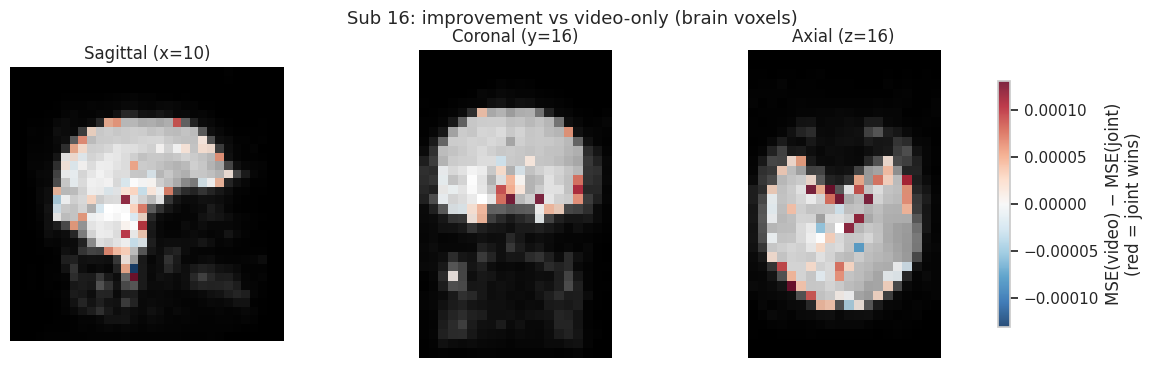

In [14]:
err_video = np.mean(
    (video_model.Y_test_predicted - np.delete(video_model.Y_test, 0, 1)) ** 2,
    axis=1,
)
imp_vs_video = err_video - err_gated

n_win = (imp_vs_video[brain_mask_flat] > 0).sum()
print(f'Within brain mask: joint model beats video-only in {n_win}/{n_total} voxels '
      f'({n_win / max(n_total, 1) * 100:.1f}%)')

show_signed_overlay(
    values_3d=imp_vs_video.reshape(gated._d1, gated._d2, gated._d3),
    bold_underlay=mean_bold,
    mask_3d=show_mask,
    title=f'Sub {SUB_ID}: improvement vs video-only (brain voxels)',
    cbar_label='MSE(video) − MSE(joint)\n(red = joint wins)',
    # save_path=f'improvement_vs_video_sub{SUB_ID}.pdf',
)

## 11 · Δt sweep — audio / video / gated

Verifies that the relative ordering of the three models is robust across
hemodynamic delays.


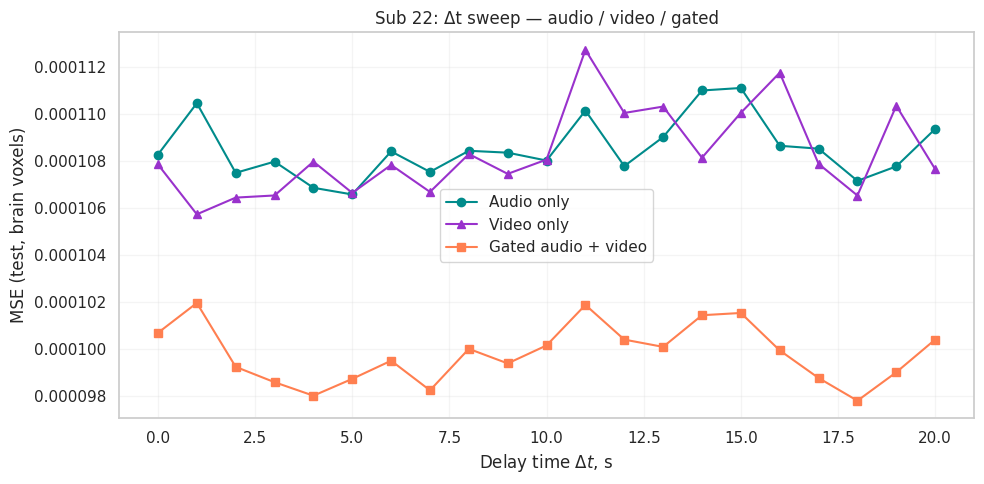

Best Δt audio:  5s  (MSE=1.0659e-04)
Best Δt video:  1s  (MSE=1.0575e-04)
Best Δt gated:  18s  (MSE=9.7819e-05)


In [10]:
t_vals = np.arange(0, 21, 1)
mse_audio, mse_video, mse_gated = [], [], []

for dt_val in t_vals:
    m_a = LinearDeltaModel(X_audio, sub, dt_val, COEF, ALPHA_A)
    m_a.fit(); m_a.predict(); m_a.evaluate(mask=brain_mask_flat)
    mse_audio.append(m_a.MSE_test)

    m_v = LinearDeltaModel(X_video, sub, dt_val, COEF, ALPHA_V)
    m_v.fit(); m_v.predict(); m_v.evaluate(mask=brain_mask_flat)
    mse_video.append(m_v.MSE_test)

    m_g = GatedMultimodalLinearDeltaModel(
        X_video=X_video, X_audio=X_audio,
        sub=sub, dt=dt_val, coef=COEF,
        alpha_video=ALPHA_V, alpha_audio=ALPHA_A,
    )
    m_g.fit(); m_g.predict(); m_g.evaluate(mask=brain_mask_flat)
    mse_gated.append(m_g.MSE_test)

plt.figure(figsize=(10, 5))
plt.plot(t_vals, mse_audio, marker='o', color='darkcyan',  label='Audio only')
plt.plot(t_vals, mse_video, marker='^', color='darkorchid', label='Video only')
plt.plot(t_vals, mse_gated, marker='s', color='coral',     label='Gated audio + video')
plt.xlabel(r'Delay time $\Delta t$, s')
plt.ylabel('MSE (test, brain voxels)')
plt.title(f'Sub {SUB_ID}: Δt sweep — audio / video / gated')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
# plt.savefig(f'mse_dt_gated_sub{SUB_ID}.pdf', bbox_inches='tight')
plt.show()

best_dt_a = t_vals[int(np.argmin(mse_audio))]
best_dt_v = t_vals[int(np.argmin(mse_video))]
best_dt_g = t_vals[int(np.argmin(mse_gated))]
print(f'Best Δt audio:  {best_dt_a}s  (MSE={min(mse_audio):.4e})')
print(f'Best Δt video:  {best_dt_v}s  (MSE={min(mse_video):.4e})')
print(f'Best Δt gated:  {best_dt_g}s  (MSE={min(mse_gated):.4e})')

## 12 · Multi-subject comparison — audio / video / gated

Sub 04 brain mask: 2366 voxels (11.6% of volume)
Sub 04:  audio=2.4141e-04  video=2.3297e-04  gated=2.2281e-04  (Δ vs A=+7.71%, Δ vs V=+4.36%, ⟨α⟩_brain=0.197)
Sub 07 brain mask: 1933 voxels (9.4% of volume)
Sub 07:  audio=1.3571e-04  video=1.3168e-04  gated=1.2471e-04  (Δ vs A=+8.11%, Δ vs V=+5.30%, ⟨α⟩_brain=0.220)
Sub 09 brain mask: 2160 voxels (10.5% of volume)
Sub 09:  audio=1.8625e-04  video=1.7700e-04  gated=1.7038e-04  (Δ vs A=+8.52%, Δ vs V=+3.74%, ⟨α⟩_brain=0.227)
Sub 11 brain mask: 2039 voxels (10.0% of volume)
Sub 11:  audio=1.4454e-04  video=1.4092e-04  gated=1.3302e-04  (Δ vs A=+7.97%, Δ vs V=+5.60%, ⟨α⟩_brain=0.209)
Sub 14 brain mask: 1759 voxels (8.6% of volume)
Sub 14:  audio=2.8202e-04  video=2.6907e-04  gated=2.4402e-04  (Δ vs A=+13.48%, Δ vs V=+9.31%, ⟨α⟩_brain=0.376)
Sub 16 brain mask: 2203 voxels (10.8% of volume)
Sub 16:  audio=4.2776e-04  video=4.0445e-04  gated=3.8119e-04  (Δ vs A=+10.89%, Δ vs V=+5.75%, ⟨α⟩_brain=0.228)
Sub 15 brain mask: 2493 voxels (12.2% of

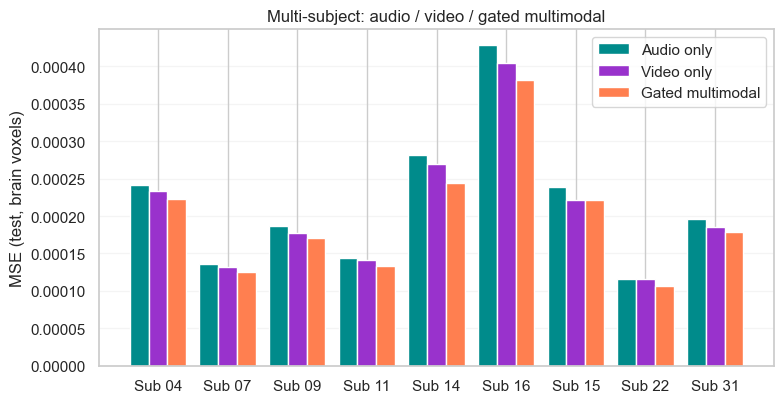

In [6]:
subjects = ['04', '07', '09', '11', '14', '16', '15', '22', '31']
results = {}

for sid in subjects:
    s = Sub(sid)                                     # uses Sub.DATA_ROOT
    s_mask = make_brain_mask_for_sub(s, COEF, var_quantile=0.10).reshape(-1)
    print(f'Sub {sid} brain mask: {int(s_mask.sum())} voxels '
          f'({s_mask.mean()*100:.1f}% of volume)')

    m_a = LinearDeltaModel(X_audio, s, DT, COEF, ALPHA_A)
    m_a.fit(); m_a.predict(); m_a.evaluate(mask=s_mask)

    m_v = LinearDeltaModel(X_video, s, DT, COEF, ALPHA_V)
    m_v.fit(); m_v.predict(); m_v.evaluate(mask=s_mask)

    m_g = GatedMultimodalLinearDeltaModel(
        X_video=X_video, X_audio=X_audio,
        sub=s, dt=DT, coef=COEF,
        alpha_video=ALPHA_V, alpha_audio=ALPHA_A,
    )
    m_g.fit(); m_g.predict(); m_g.evaluate(mask=s_mask)

    delta_a = (m_a.MSE_test - m_g.MSE_test) / m_a.MSE_test * 100
    delta_v = (m_v.MSE_test - m_g.MSE_test) / m_v.MSE_test * 100
    results[sid] = {
        'audio':         m_a.MSE_test,
        'video':         m_v.MSE_test,
        'gated':         m_g.MSE_test,
        'delta_vs_a':    delta_a,
        'delta_vs_v':    delta_v,
        'alpha_mean':    float(m_g.alpha[s_mask].mean()),
    }
    print(
        f'Sub {sid}:  audio={m_a.MSE_test:.4e}  video={m_v.MSE_test:.4e}  '
        f'gated={m_g.MSE_test:.4e}  '
        f'(Δ vs A={delta_a:+.2f}%, Δ vs V={delta_v:+.2f}%, '
        f'⟨α⟩_brain={m_g.alpha[s_mask].mean():.3f})'
    )

# Three-bar group plot
x = np.arange(len(subjects))
w = 0.27
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(x - w, [results[s]['audio'] for s in subjects], w,
       color='darkcyan',  label='Audio only')
ax.bar(x,     [results[s]['video'] for s in subjects], w,
       color='darkorchid', label='Video only')
ax.bar(x + w, [results[s]['gated'] for s in subjects], w,
       color='coral',     label='Gated multimodal')
ax.set_xticks(x)
ax.set_xticklabels([f'Sub {s}' for s in subjects])
ax.set_ylabel('MSE (test, brain voxels)')
ax.set_title('Multi-subject: audio / video / gated multimodal')
ax.legend()
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
# plt.savefig('mse_subjects_gated.pdf', bbox_inches='tight')
plt.show()

In [ ]:

import numpy as np
import pandas as pd
from scipy.stats import wilcoxon, binomtest, friedmanchisquare, norm
from statsmodels.stats.multitest import multipletests



subjects_ordered = ['04', '07', '09', '11', '14', '15', '16', '22', '31']
mse_audio = np.array([results[s]['audio'] for s in subjects_ordered])
mse_video = np.array([results[s]['video'] for s in subjects_ordered])
mse_gated = np.array([results[s]['gated'] for s in subjects_ordered])
n = len(subjects_ordered)

print(f'Парных наблюдений: n = {n}')
print(f'MSE audio:  mean={mse_audio.mean():.4e}, median={np.median(mse_audio):.4e}')
print(f'MSE video:  mean={mse_video.mean():.4e}, median={np.median(mse_video):.4e}')
print(f'MSE gated:  mean={mse_gated.mean():.4e}, median={np.median(mse_gated):.4e}')
print()



stat_fr, p_fr = friedmanchisquare(mse_audio, mse_video, mse_gated)
print('Friedman test (групповая проверка различий между моделями):')
print(f'  χ²(df=2) = {stat_fr:.3f},  p = {p_fr:.4f}')
print(f'  → {"различия есть → переходим к попарным тестам" if p_fr < 0.05 else "различий нет, дальше можно не идти"}')
print()




W_a, p_w_a = wilcoxon(mse_gated, mse_audio, alternative='less')
W_v, p_w_v = wilcoxon(mse_gated, mse_video, alternative='less')



n_wins_a = int((mse_gated < mse_audio).sum())
n_wins_v = int((mse_gated < mse_video).sum())
p_s_a = binomtest(n_wins_a, n, p=0.5, alternative='greater').pvalue
p_s_v = binomtest(n_wins_v, n, p=0.5, alternative='greater').pvalue



p_raw = [p_w_a, p_w_v]
reject, p_holm, _, _ = multipletests(p_raw, alpha=0.05, method='holm')



z_a = norm.ppf(max(p_w_a, 1e-12))
z_v = norm.ppf(max(p_w_v, 1e-12))
r_a = abs(z_a) / np.sqrt(n)
r_v = abs(z_v) / np.sqrt(n)

def effect_label(r):
    if r < 0.3:   return 'малый'
    if r < 0.5:   return 'средний'
    return 'большой'



def boot_mean_ci(x, n_boot=10000, alpha=0.05, seed=0):
    """Перцентильный бутстрэп среднего."""
    rng = np.random.default_rng(seed)
    boots = rng.choice(x, size=(n_boot, len(x)), replace=True).mean(axis=1)
    lo, hi = np.percentile(boots, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float(x.mean()), float(lo), float(hi)

rel_a = (mse_audio - mse_gated) / mse_audio * 100          # % редукции
rel_v = (mse_video - mse_gated) / mse_video * 100

m_a, lo_a, hi_a = boot_mean_ci(rel_a)
m_v, lo_v, hi_v = boot_mean_ci(rel_v)



summary = pd.DataFrame({
    'Сравнение':       ['Gated vs Audio',  'Gated vs Video'],
    'Wilcoxon W':      [f'{W_a:.1f}',       f'{W_v:.1f}'],
    'p (raw)':         [f'{p_w_a:.4f}',     f'{p_w_v:.4f}'],
    'p (Holm)':        [f'{p_holm[0]:.4f}', f'{p_holm[1]:.4f}'],
    'H0 (α=0.05)':     ['отвергнута' if reject[0] else 'не отвергнута',
                        'отвергнута' if reject[1] else 'не отвергнута'],
    'Знаковый: wins':  [f'{n_wins_a}/{n}',  f'{n_wins_v}/{n}'],
    'p (sign)':        [f'{p_s_a:.4f}',     f'{p_s_v:.4f}'],
    'Δ MSE, %':        [f'{m_a:+.2f}',      f'{m_v:+.2f}'],
    '95% CI':          [f'[{lo_a:+.2f}, {hi_a:+.2f}]',
                        f'[{lo_v:+.2f}, {hi_v:+.2f}]'],
    'Effect size r':   [f'{r_a:.2f} ({effect_label(r_a)})',
                        f'{r_v:.2f} ({effect_label(r_v)})'],
})


print('Сводная таблица статистических тестов:')
print()
print(summary.to_string(index=False))
print()


Парных наблюдений: n = 9
MSE audio:  mean=2.1858e-04, median=1.9577e-04
MSE video:  mean=2.0864e-04, median=1.8477e-04
MSE gated:  mean=1.9796e-04, median=1.7861e-04

Friedman test (групповая проверка различий между моделями):
  χ²(df=2) = 16.222,  p = 0.0003
  → различия есть → переходим к попарным тестам

Сводная таблица статистических тестов:

     Сравнение Wilcoxon W p (raw) p (Holm) H0 (α=0.05) Знаковый: wins p (sign) Δ MSE, %          95% CI  Effect size r
Gated vs Audio        0.0  0.0020   0.0039  отвергнута            9/9   0.0020    +8.99 [+7.97, +10.33] 0.96 (большой)
Gated vs Video        0.0  0.0020   0.0039  отвергнута            9/9   0.0020    +5.10  [+3.36, +6.80] 0.96 (большой)



## 13 · Per-subject α maps (overlaid)

Side-by-side comparison of the gating maps for each subject, all on
their own brain anatomy and within their own confidence mask.


In [ ]:
fig, axes = plt.subplots(1, len(subjects), figsize=(5 * len(subjects), 4))
if len(subjects) == 1:
    axes = [axes]

for ax, sid in zip(axes, subjects):
    s = Sub(sid)

    m_g = GatedMultimodalLinearDeltaModel(
        X_video=X_video, X_audio=X_audio,
        sub=s, dt=DT, coef=COEF,
        alpha_video=ALPHA_V, alpha_audio=ALPHA_A,
    )
    m_g.fit(); m_g.predict()

    bm = make_brain_mask_for_sub(s, COEF, var_quantile=0.10)
    cm = m_g.confidence_volume(
        predictability_quantile=0.5, separability_quantile=0.3,
    )
    mask = bm & cm

    underlay = m_g.mean_bold_volume()
    a3d = m_g.alpha_volume()
    sl = a3d.shape[2] // 2

    ax.imshow(underlay[:, :, sl].T, cmap='gray', origin='lower')
    masked = np.where(mask[:, :, sl], a3d[:, :, sl], np.nan).T
    cmap = plt.get_cmap('RdBu_r').copy(); cmap.set_bad(alpha=0.0)
    im = ax.imshow(masked, cmap=cmap, origin='lower',
                   vmin=0, vmax=1, alpha=0.85)
    ax.set_title(f'Sub {sid}  (z={sl})')
    ax.axis('off')

fig.colorbar(im, ax=axes,
             label=r'$\alpha$ (red = video, blue = audio)', shrink=0.8)
fig.suptitle('Per-subject α maps (gated multimodal, mid-axial)',
             fontsize=13)
plt.savefig('alpha_grid_subjects.pdf', bbox_inches='tight')
plt.show()
